In [1]:
import pandas as pd 
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import json
import mne
import numpy as np
from tqdm import tqdm
import re
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from multiprocessing import Pool
import warnings

warnings.filterwarnings("ignore")

os.chdir('../..')

# Load Morlet PSDs

In [2]:
#loaded = np.load('./Generated/Spectrums/psds_array_morlet.npz')
loaded = np.load('C:/Users/dasga/PycharmProjects/EEG/EEG-Image-Reconstruction/Generated/Spectrums/psds_array_morlet.npz')

results_arr = []

i = 0
while f'psd_{i}' in loaded:
    psd = loaded[f'psd_{i}']
    s_id = int(loaded[f'subject_id_{i}'])
    t_id = int(loaded[f'trial_id_{i}'])
    gender = str(loaded[f'gender_{i}'])
    handiness = str(loaded[f'handiness_{i}'])
    age = int(loaded[f'age_{i}'])
    
    results_arr.append([psd, s_id, t_id, gender, handiness, age])
    i += 1

psd, s_id, t_id, gender, handiness, age = results_arr[0]
psd.shape

(63, 80)

In [3]:
# Parse into two lists will be used furthere
psds_array = [item[0] for item in results_arr]
psds_array = np.array(psds_array)                            # Convert list of PSDs to a numpy array
psds_array = psds_array.reshape((psds_array.shape[0], -1))   # Vectorize 

metadata = [item[1:] for item in results_arr]

psds_array.shape

(31, 5040)

### Normalize Each Spectrum
Why not to normalize by channels? - Because the chennel relevance to each other may be lost. For instance some chanels may have higher power for particular freq band.

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
psds_array = scaler.fit_transform(psds_array)

# Dimentionality Reduction
Every method produces `reduced_data` variable wich is `27xN` shape, where `N` is the reduction dimentionality.

### PCA

In [5]:
from sklearn.decomposition import PCA

# Assuming 'psds_array' is your high-dimensional data
N = 18
pca = PCA(n_components=N, random_state=42)
reduced_data = pca.fit_transform(psds_array)
reduced_data.shape

(31, 18)

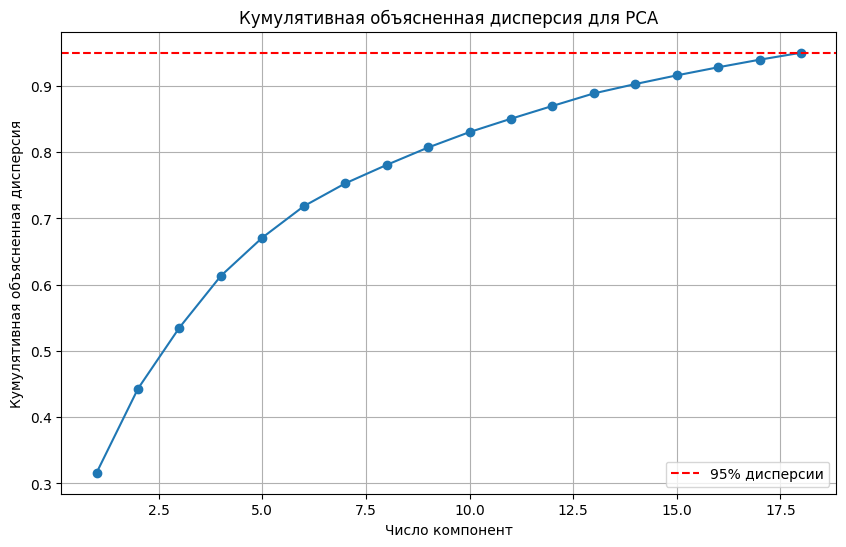

In [6]:
# Анализ объясненной дисперсии
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Визуализация кумулятивной дисперсии
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.xlabel('Число компонент')
plt.ylabel('Кумулятивная объясненная дисперсия')
plt.title('Кумулятивная объясненная дисперсия для PCA')
plt.grid(True)
plt.legend()
plt.show()

# Best 17 dim

# Clusterization
* `KNN` - 
* `DBSCAN` - 
* `HDBSCAN` -
* `GMM` -
* `Spectral Clustering` -
* `Agglomerative` - 

### KNN
Best for `PCA` k=2 (Но оно всеравно меньше 0.5, а значит не столь надежно)

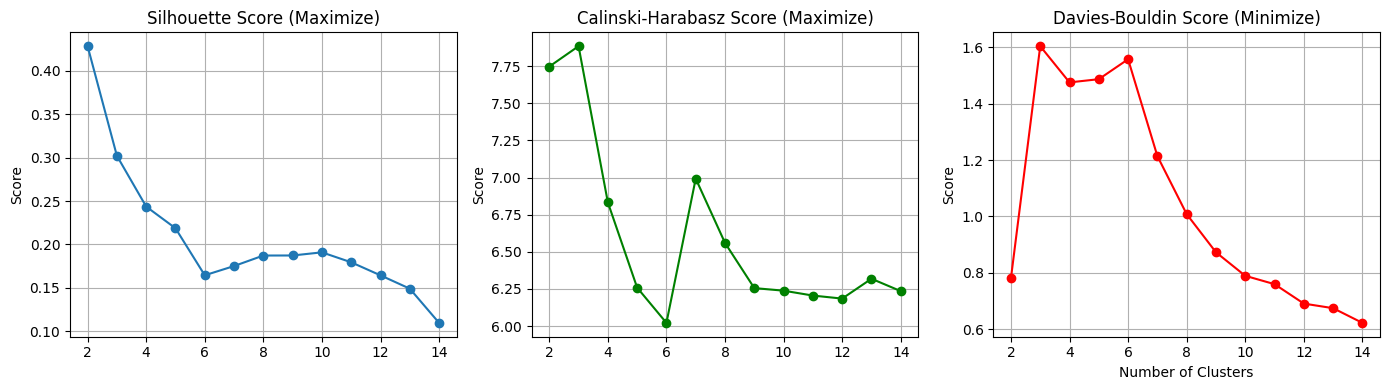

In [7]:
from sklearn.cluster import KMeans

silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(reduced_data)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [8]:
k = 2  # предположительное количество кластеров
kmeans = KMeans(n_clusters=k, random_state=42)
labels_knn = kmeans.fit_predict(reduced_data)

### DBSCAN
Best for `PCA` - Излом на 90

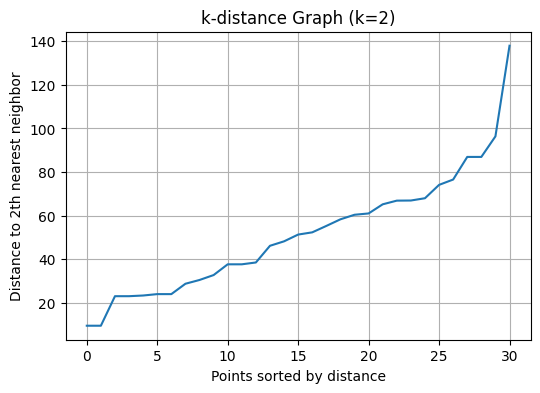

In [9]:
from sklearn.neighbors import NearestNeighbors

min_samples = 2
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(reduced_data)
distances, indices = neighbors_fit.kneighbors(reduced_data)

# берем расстояние до k-го соседа (по столбцу)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.title(f"k-distance Graph (k={min_samples})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.grid(True)
plt.show()



In [10]:
from sklearn.cluster import DBSCAN

# DBSCAN clustering in high-dimensional space
dbscan = DBSCAN(eps=90, min_samples=2)  # eps можно варьировать
labels_dbscan = dbscan.fit_predict(reduced_data)

### HDBSCAN

In [11]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=2)
labels_hdbscan = clusterer.fit_predict(reduced_data)

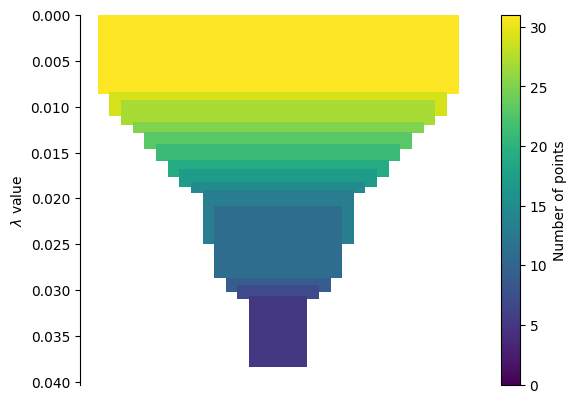

In [12]:
clusterer.condensed_tree_.plot()
pass

### GMM
`n_components`: количество гауссовых компонентов. Подбирается через BIC:

BIC (Bayesian Information Criterion) — это метрика, которая балансирует:

качество подгонки модели (log-likelihood — чем выше, тем лучше)

сложность модели (штраф за число параметров)


Best for `PCA` - minimum bic is for 5 components

Best for `UMAP` - minimum bic is for 3 components

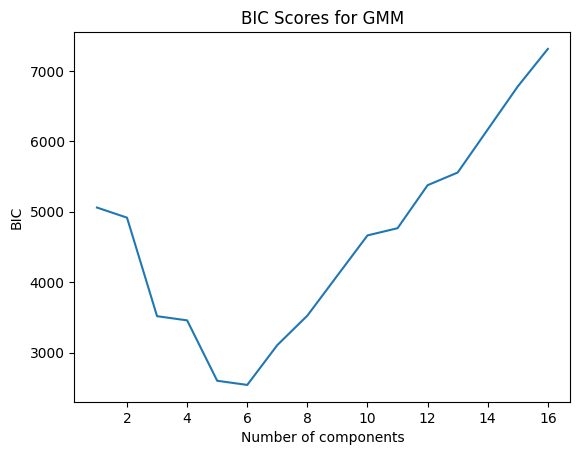

In [13]:
from sklearn.mixture import GaussianMixture

bic_scores = []
for n in range(1, 17):
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(reduced_data)
    bic_scores.append(gmm.bic(reduced_data))

plt.plot(range(1, 17), bic_scores)
plt.title("BIC Scores for GMM")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.show()

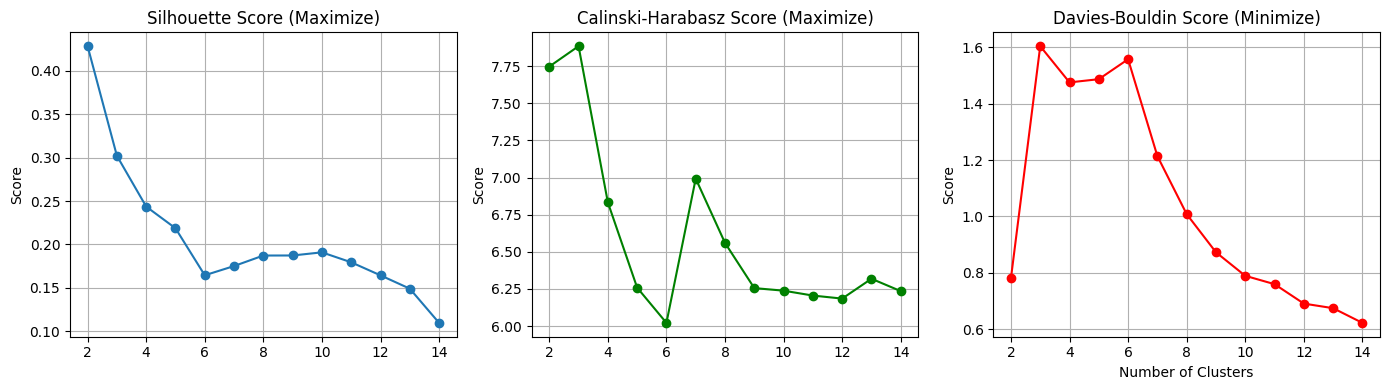

In [14]:
silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(reduced_data)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [15]:
gmm = GaussianMixture(n_components=6, random_state=42)
labels_gmm = gmm.fit_predict(reduced_data)

### Spectral Clustering

Best for `PCA` - 4 clusters (max score)

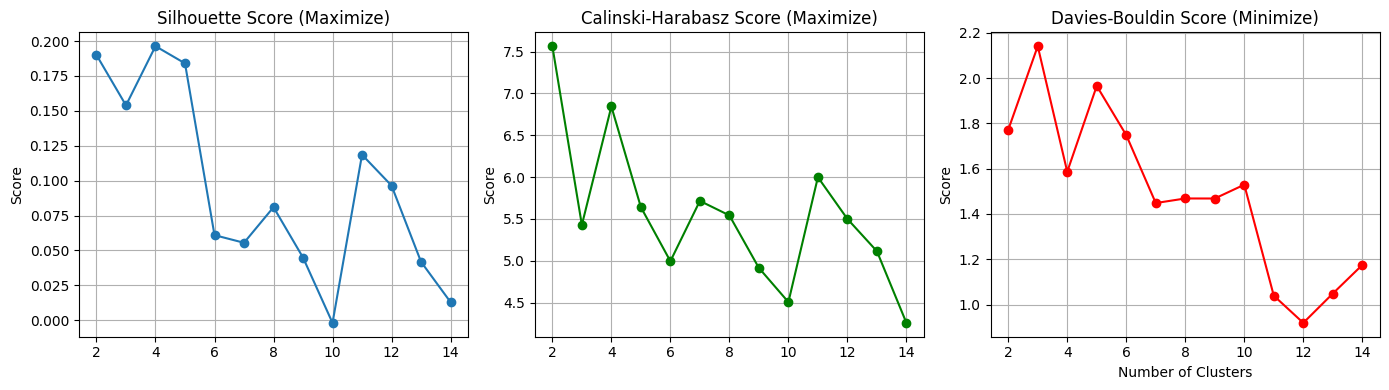

In [16]:
from sklearn.cluster import SpectralClustering

silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
    labels = spec.fit_predict(psds_array)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [17]:
spec = SpectralClustering(n_clusters=4, affinity='nearest_neighbors', random_state=42)
labels_spec_clust = spec.fit_predict(psds_array)

### Agglomerative

Best for `PCA` - 3 clusters (max score)

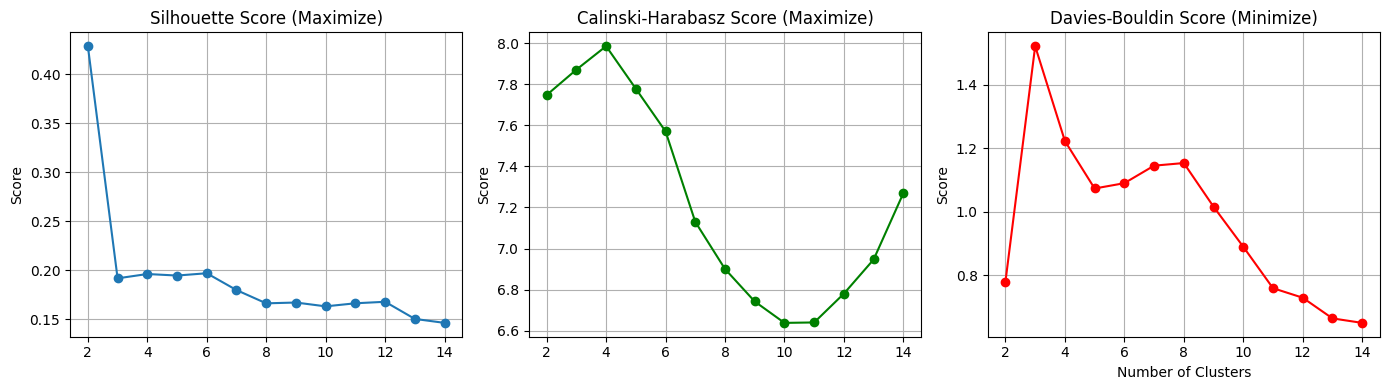

In [18]:
from sklearn.cluster import AgglomerativeClustering

silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(reduced_data)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [19]:
# Иерархическая кластеризация с заданным числом кластеров
model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agglomerative = model.fit_predict(reduced_data)

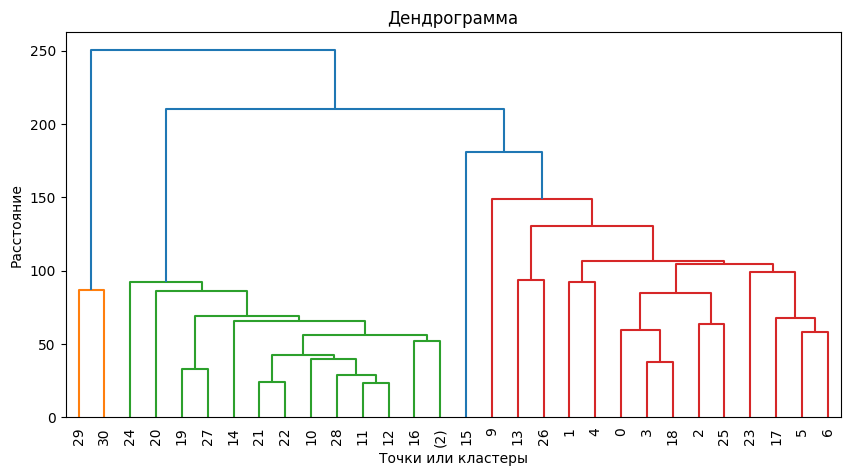

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(reduced_data, method='ward')  # метод linkage должен соответствовать
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90.)
plt.title('Дендрограмма')
plt.xlabel('Точки или кластеры')
plt.ylabel('Расстояние')
plt.show()

In [21]:
from datetime import datetime, time as dtime

# Используем тот же файл и приём, что в Compute_*_All
file_path = 'C:/Users/dasga/PycharmProjects/EEG/EEG-Image-Reconstruction/Supplementary/Experiment_Metadata.xlsx'
df_raw = pd.read_excel(file_path, header=1)

# Переименования как там
df_raw = df_raw.rename(columns={
    'Subject ID'     : 'Subject_id',
    'Имя'            : 'Name',
    'Фамилия'        : 'Surname',
    'Дата Рождения'  : 'Birthdate',
    'Пол'            : 'Gender',
    'Правша / Левша' : 'Handiness',
    'Время'          : 'Time',       # если колонка на рус
})

# Преобразование пола/латерализации в латиницу (как в compute_all)
gender_map = {'М':'m', 'Ж':'f', 'м':'m', 'ж':'f'}
if 'Gender' in df_raw.columns:
    df_raw['Gender'] = df_raw['Gender'].map(gender_map).fillna(df_raw['Gender'])

hand_map = {'Правша':'r', 'Левша':'l', 'правша':'r', 'левша':'l'}
if 'Handiness' in df_raw.columns:
    df_raw['Handiness'] = df_raw['Handiness'].map(hand_map).fillna(df_raw['Handiness'])

# Возраст (как в твоих Compute): Birthdate -> Age и удаляем Birthdate
if 'Birthdate' in df_raw.columns:
    df_raw['Birthdate'] = pd.to_datetime(df_raw['Birthdate'], dayfirst=True, errors='coerce')
    today = pd.Timestamp.today().normalize()
    def calc_age(bd):
        if pd.isna(bd): return 0
        years = today.year - bd.year
        if (today.month, today.day) < (bd.month, bd.day): years -= 1
        return int(years)
    df_raw['Age'] = df_raw['Birthdate'].apply(calc_age).fillna(0).astype(int)
    df_raw = df_raw.drop(columns=['Birthdate'])

# Индекс — Subject_id
if 'Subject_id' not in df_raw.columns:
    raise KeyError("В метаданных нет 'Subject_id' после переименования.")
subject_metadata = df_raw.set_index('Subject_id')

# Аккуратный парсинг времени: поддержка excel-чисел и строк/дат
def _to_time(series: pd.Series) -> pd.Series:
    if series.name is None:
        series.name = 'Time'
    s = series
    if np.issubdtype(s.dtype, np.number):
        vals = s.to_numpy(dtype=float)
        if np.nanmax(vals) <= 1.5:  # доля суток
            secs = np.nan_to_num(vals) * 24 * 3600.0
            return pd.to_timedelta(secs, unit='s').map(lambda td: (pd.Timestamp.min + td).time())
    dt = pd.to_datetime(s, errors='coerce')
    if dt.isna().any():
        raise ValueError("Часть значений времени не распарсилась (NaT). Проверь формат Time.")
    return dt.dt.time

# Находим колонку времени
time_col = 'Time' if 'Time' in subject_metadata.columns else None
if time_col is None:
    # fallback — попробуем популярные названия
    for cand in ['Время начала записи']:
        if cand in subject_metadata.columns:
            subject_metadata = subject_metadata.rename(columns={cand: 'Time'})
            time_col = 'Time'; break
if time_col is None:
    raise KeyError("Не нашли колонку 'Time' в метаданных.")

subject_metadata['__time'] = _to_time(subject_metadata['Time'])
subject_metadata[['__time']].head()


,__time
Subject_id,
1,18:00:00
2,20:00:00
3,13:00:00
4,16:00:00
5,19:00:00


# Search Space Visualization

In [22]:
from sklearn.decomposition import PCA

# Assuming 'psds_array' is your high-dimensional data
N = 3
pca = PCA(n_components=N, random_state=42)
reduced_data = pca.fit_transform(psds_array)
reduced_data.shape

(31, 3)

In [23]:
# from sklearn.manifold import TSNE

# N = 3  # Размерность после снижения
# reducer = TSNE(n_components=N, random_state=42, perplexity=10, max_iter=10000, metric='euclidean')
# reduced_data = reducer.fit_transform(psds_array)

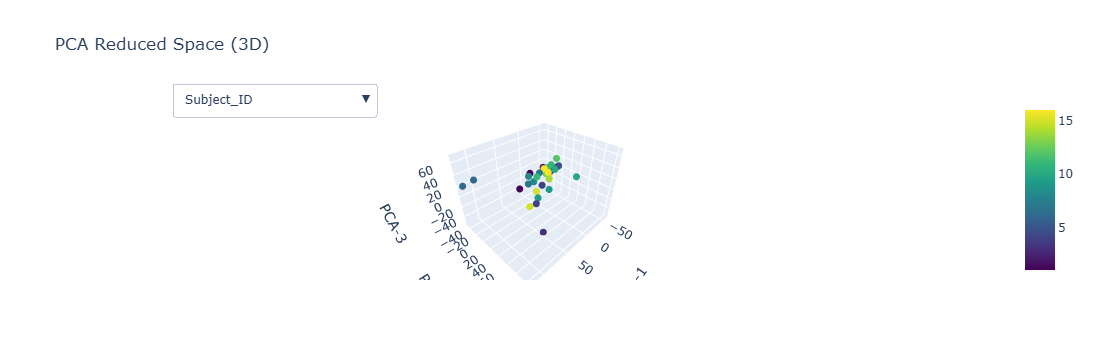

In [26]:
from plotly import colors as pc

method = 'PCA'
dim = 3  # Can be 2 or 3

subject_ids = [meta[0] for meta in metadata]
trial_ids = [meta[1] for meta in metadata]
gender = [meta[2] for meta in metadata]
handiness = [meta[3] for meta in metadata]
age = [meta[4] for meta in metadata]

# Маппим время к каждой записи по Subject_ID (если в Excel есть Trial_id — можно расширить merge)
times = []
for sid in subject_ids:
    try:
        t = subject_metadata.loc[int(sid), '__time']
        # если у субъекта несколько строк в Excel — берём первую
        if isinstance(t, pd.Series):
            t = t.iloc[0]
        times.append(t)
    except Exception:
        times.append(None)

def _cond_from_time(t, day_start=10, day_end=18, eve_start=18, eve_end=24):
    if t is None:
        return 'other'
    h = int(t.hour)

    def in_window(a, b, h):
        # [a, b) с поддержкой обёртки через полночь; b может быть 24
        if a == b:
            return True  # весь круг
        if a < b:
            return a <= h < b
        # окно через полночь, например [22, 3)
        return (h >= a) or (h < b)

    if in_window(day_start, day_end, h):
        return 'day'
    if in_window(eve_start, eve_end, h):
        return 'evening'
    return 'other'

conditions = [_cond_from_time(t) for t in times]

# Adjust DataFrame columns based on dim
columns = [f'DIM-{i+1}' for i in range(dim)]
df = pd.DataFrame(reduced_data, columns=columns)
df['Subject_ID'] = subject_ids
df['Trial_ID'] = trial_ids
df['Gender'] = gender
df['Handiness'] = handiness
df['Age'] = age
df['Labels_DBSCAN'] = labels_dbscan
df['Labels_KNN'] = labels_knn
df['Labels_HDBSCAN'] = labels_hdbscan
df['Labels_GMM'] = labels_gmm
df['Labels_Spectral_Clustering'] = labels_spec_clust
df['Labels_Agglomerative'] = labels_agglomerative
df['Metadata'] = [str(meta) for meta in metadata]

df['Time'] = [t.strftime('%H:%M') if t is not None else None for t in times]  # человекочитаемо
df['Condition'] = conditions 

_CAT_PALETTE = (pc.qualitative.Plotly + pc.qualitative.D3 +
                pc.qualitative.Safe + pc.qualitative.Set3 +
                pc.qualitative.Pastel)

def _color_kwargs(series: pd.Series):
    s = pd.Series(series)

    # числовые столбцы → непрерывная шкала
    if pd.api.types.is_numeric_dtype(s):
        return {'color': s.to_numpy(), 'colorscale': 'Viridis', 'showscale': True}

    s_str = s.astype(str)

    # формат времени 'HH:MM' → переводим в минуты суток
    if s_str.dropna().str.match(r'^\d{1,2}:\d{2}$').all():
        dt = pd.to_datetime(s_str, format='%H:%M', errors='coerce')
        mins = (dt.dt.hour * 60 + dt.dt.minute).astype(float)
        return {'color': mins.to_numpy(), 'colorscale': 'Viridis', 'showscale': True}

    # категориальные значения → дискретные цвета
    cats = s_str.fillna('NA').unique()
    lut = {cat: _CAT_PALETTE[i % len(_CAT_PALETTE)] for i, cat in enumerate(cats)}
    mapped = s_str.fillna('NA').map(lut)
    return {'color': mapped.to_numpy()}

coloring_vars = [
    'Subject_ID', 'Trial_ID', 'Gender', 'Handiness', 'Age',
    'Labels_DBSCAN', 'Labels_KNN', 'Labels_HDBSCAN', 'Labels_GMM',
    'Labels_Spectral_Clustering', 'Labels_Agglomerative',
    'Condition', 'Time'
]

fig = go.Figure()

for i, var in enumerate(coloring_vars):
    if var not in df.columns:
        continue

    mkw = _color_kwargs(df[var])  # корректные параметры для marker

    if dim == 3:
        fig.add_trace(go.Scatter3d(
            x=df['DIM-1'], y=df['DIM-2'], z=df['DIM-3'],
            mode='markers',
            marker=dict(size=4, **mkw),
            hoverinfo='text',
            hovertext=df['Metadata'],
            name=var,
            visible=(i == 0)  # показываем первый слой по умолчанию
        ))
    else:
        fig.add_trace(go.Scatter(
            x=df['DIM-1'], y=df['DIM-2'],
            mode='markers',
            marker=dict(size=6, **mkw),
            hoverinfo='text',
            hovertext=df['Metadata'],
            name=var,
            visible=(i == 0)
        ))

# Кнопки для переключения раскраски
buttons = []
for i, var in enumerate(coloring_vars):
    buttons.append(dict(
        label=var,
        method='update',
        args=[{'visible': [j == i for j in range(len(coloring_vars))]}]
    ))

# ------------------------
# 6) Оформление и сохранение
# ------------------------
if dim == 3:
    fig.update_layout(
        updatemenus=[dict(
            buttons=buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.1, xanchor='left',
            y=1.15, yanchor='top'
        )],
        title=f'{method} Reduced Space ({dim}D)',
        scene=dict(
            xaxis_title=f'{method}-1',
            yaxis_title=f'{method}-2',
            zaxis_title=f'{method}-3'
        ),
        showlegend=False
    )
else:
    fig.update_layout(
        updatemenus=[dict(
            buttons=buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.1, xanchor='left',
            y=1.15, yanchor='top'
        )],
        title=f'{method} Reduced Space ({dim}D)',
        xaxis_title=f'{method}-1',
        yaxis_title=f'{method}-2',
        showlegend=False
    )

fig.show()

#fig.write_html(f'./Generated/Figures/Spectral_Analysis/Spectral_Clustering/All/Morlet_PCA_All_Clust_3D.html', include_plotlyjs='cdn', full_html=True)

In [28]:
# параметры анализа
EMBEDDING_MODE = 'raw'     # 'raw' (без DR), 'pca_keep' (мягкая PCA), 'pca_ready' (твой reduced_data)
PCA_KEEP_N     = 8         # число компонент при 'pca_keep'
DISTANCE       = 'cosine'  # 'cosine' или 'euclidean' для метрики центроидов
N_CLUSTERS     = 4         # кластеры в каждом условии для варианта A
N_NEIGHBORS    = 15        # граф соседей для SpectralClustering
K_GLOBAL       = 6         # число кластеров для глобального KMeans в варианте B
RANDOM_STATE   = 42
N_PERM         = 500       # число перестановок (0 — отключить)

SAVE_FIGS      = False
FIG_DIR        = './Generated/Spectral_Analysis/Diagnostics'


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, ks_2samp, mannwhitneyu
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import os

def select_embedding(psds_array, reduced_data, mode='raw', keep_n=8, seed=42):
    if mode == 'raw':
        Z = psds_array
        tag = f'RAW (dims={Z.shape[1]})'
    elif mode == 'pca_keep':
        pca = PCA(n_components=min(keep_n, psds_array.shape[1]), random_state=seed)
        Z = pca.fit_transform(psds_array)
        tag = f'PCA_keep (n={Z.shape[1]})'
    else:
        Z = reduced_data
        tag = f'PCA_ready (n={Z.shape[1]})'
    return Z, tag

def spectral_labels(X, k, n_neighbors, seed):
    nn = min(max(5, n_neighbors), max(5, X.shape[0]-1))
    k = min(k, max(2, X.shape[0]//2))  # не больше половины выборки
    model = SpectralClustering(
        n_clusters=k, affinity='nearest_neighbors',
        n_neighbors=nn, assign_labels='kmeans', random_state=seed
    )
    return model.fit_predict(X), k

def centroids(X, y):
    labs = sorted(np.unique(y))
    return np.vstack([X[y==lab].mean(axis=0) for lab in labs])

def match_distance(C1, C2, metric='cosine'):
    D = cosine_distances(C1, C2) if metric == 'cosine' else euclidean_distances(C1, C2)
    r, c = linear_sum_assignment(D)
    return D, r, c, float(D[r, c].mean())

def rbf_mmd2_unbiased(X, Y, gamma):
    XX = np.exp(-gamma * euclidean_distances(X, X, squared=True))
    YY = np.exp(-gamma * euclidean_distances(Y, Y, squared=True))
    XY = np.exp(-gamma * euclidean_distances(X, Y, squared=True))
    n, m = len(X), len(Y)
    if n < 2 or m < 2: 
        return np.nan
    np.fill_diagonal(XX, 0.0)
    np.fill_diagonal(YY, 0.0)
    term_xx = XX.sum() / (n*(n-1))
    term_yy = YY.sum() / (m*(m-1))
    term_xy = 2.0 * XY.mean()
    return float(term_xx + term_yy - term_xy)

def maybe_save(fig, name):
    if SAVE_FIGS:
        os.makedirs(FIG_DIR, exist_ok=True)
        p = os.path.join(FIG_DIR, name)
        fig.savefig(p, dpi=150, bbox_inches='tight')
        print("saved:", p)


In [32]:
# Z и тэг
Z, used_space = select_embedding(psds_array, reduced_data, EMBEDDING_MODE, PCA_KEEP_N, RANDOM_STATE)

conds = df['Condition'].astype(str).to_numpy()
mask_day = (conds == 'day')
mask_eve = (conds == 'evening')

print(f"[Space: {used_space}. Samples: day={mask_day.sum()}, evening={mask_eve.sum()} (total={len(Z)})")


[Space: RAW (dims=5040). Samples: day=17, evening=14 (total=31)


[A] Mean matched centroid distance (day-evening): 0.8819  | metric=cosine  (k_day=4, k_eve=4)
[A] permutation p-value (>=obs): 0.2216


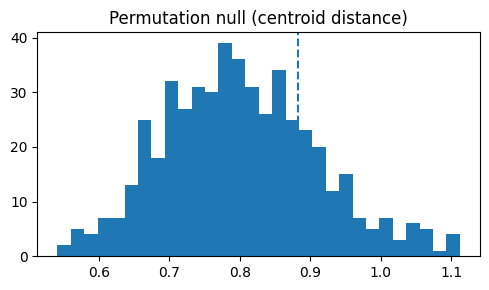

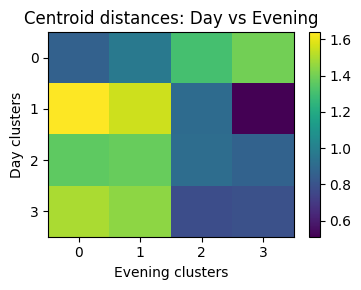

In [35]:
resA = {}

if (mask_day.sum() >= max(2, N_CLUSTERS)) and (mask_eve.sum() >= max(2, N_CLUSTERS)):
    Z_day, Z_eve = Z[mask_day], Z[mask_eve]
    y_day, kD = spectral_labels(Z_day, N_CLUSTERS, N_NEIGHBORS, RANDOM_STATE)
    y_eve, kE = spectral_labels(Z_eve, N_CLUSTERS, N_NEIGHBORS, RANDOM_STATE)

    C_day = centroids(Z_day, y_day)
    C_eve = centroids(Z_eve, y_eve)

    Dmat, r, c, mean_min = match_distance(C_day, C_eve, DISTANCE)
    print(f"[A] Mean matched centroid distance (day-evening): {mean_min:.4f}  | metric={DISTANCE}  (k_day={kD}, k_eve={kE})")
    resA.update(dict(mean=mean_min, D=Dmat))

    if N_PERM > 0:
        rng = np.random.default_rng(RANDOM_STATE)
        nD, nE = len(Z_day), len(Z_eve)
        Xall = np.vstack([Z_day, Z_eve])
        vals = np.zeros(N_PERM, float)
        for i in range(N_PERM):
            idx = rng.permutation(len(Xall))
            X1, X2 = Xall[idx[:nD]], Xall[idx[nD:nD+nE]]
            y1, _ = spectral_labels(X1, N_CLUSTERS, N_NEIGHBORS, RANDOM_STATE+i+1)
            y2, _ = spectral_labels(X2, N_CLUSTERS, N_NEIGHBORS, RANDOM_STATE+i+2)
            C1, C2 = centroids(X1, y1), centroids(X2, y2)
            _,_,_, mv = match_distance(C1, C2, DISTANCE)
            vals[i] = mv
        p_ge = (1 + (vals >= mean_min).sum()) / (N_PERM + 1)
        print(f"[A] permutation p-value (>=obs): {p_ge:.4f}")
        resA['p_perm'] = float(p_ge)

        fig = plt.figure(figsize=(5,3))
        plt.hist(vals, bins=30); plt.axvline(mean_min, ls='--')
        plt.title('Permutation null (centroid distance)')
        plt.tight_layout(); plt.show()
        maybe_save(fig, 'A_permutation_null.png')

    fig = plt.figure(figsize=(4,3))
    plt.imshow(Dmat, aspect='auto')
    plt.title('Centroid distances: Day vs Evening')
    plt.xlabel('Evening clusters'); plt.ylabel('Day clusters')
    plt.colorbar(); plt.tight_layout(); plt.show()
    maybe_save(fig, 'A_centroid_distance_matrix.png')
else:
    print("[A] Недостаточно точек для заданного N_CLUSTERS — пропуск.")


In [36]:
km = KMeans(n_clusters=K_GLOBAL, random_state=RANDOM_STATE)
labels_global = km.fit_predict(Z)

cont = pd.crosstab(pd.Series(conds, name='Condition'), pd.Series(labels_global, name='Cluster'))
chi2, p_chi, dof, exp = chi2_contingency(cont.values)
print(f"[B] χ² test (cluster proportions day vs evening): p = {p_chi:.4f}")
display(cont)


[B] χ² test (cluster proportions day vs evening): p = 0.1352


Cluster,0,1,2,3,4,5
Condition,,,,,,
day,2,2,2,7,3,1
evening,5,0,0,7,0,2


[C1] MMD^2 (RBF) = 0.0762, permutation p = 0.0060


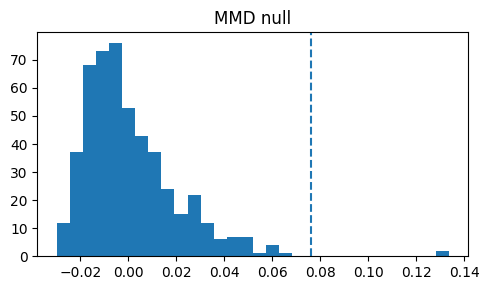

In [37]:
X_day, X_eve = Z[mask_day], Z[mask_eve]
resC1 = {}

if len(X_day) > 0 and len(X_eve) > 0:
    pair_d2 = euclidean_distances(np.vstack([X_day, X_eve]), squared=True)
    med = np.median(pair_d2[np.triu_indices_from(pair_d2, k=1)])
    gamma = 1.0 / (med + 1e-12)

    mmd_obs = rbf_mmd2_unbiased(X_day, X_eve, gamma)
    p_mmd = None
    if N_PERM > 0 and not np.isnan(mmd_obs):
        rng = np.random.default_rng(RANDOM_STATE+123)
        allX = np.vstack([X_day, X_eve])
        nD = len(X_day)
        vals = np.zeros(N_PERM, float)
        for i in range(N_PERM):
            idx = rng.permutation(len(allX))
            X1, X2 = allX[idx[:nD]], allX[idx[nD:]]
            vals[i] = rbf_mmd2_unbiased(X1, X2, gamma)
        p_mmd = (1 + (vals >= mmd_obs).sum()) / (N_PERM + 1)
        print(f"[C1] MMD^2 (RBF) = {mmd_obs:.4f}, permutation p = {p_mmd:.4f}")

        fig = plt.figure(figsize=(5,3))
        plt.hist(vals, bins=30); plt.axvline(mmd_obs, ls='--')
        plt.title('MMD null')
        plt.tight_layout(); plt.show()
        maybe_save(fig, 'C1_MMD_null.png')
    else:
        print(f"[C1] MMD^2 (RBF) = {mmd_obs:.4f} (перестановки отключены или мало точек)")

    resC1.update(dict(mmd=mmd_obs, p=p_mmd))
else:
    print("[C1] одна из групп пуста — пропуск.")


[C2] LDA 1D: KS p = 0.0000,  Mann–Whitney p = 0.0000


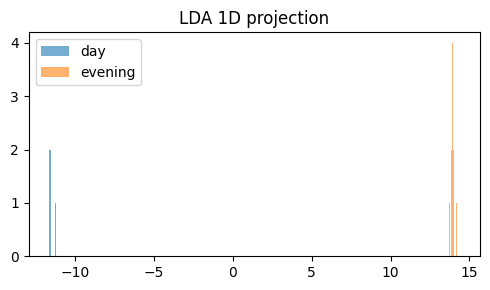

In [38]:
resC2 = {}

if mask_day.any() and mask_eve.any():
    mask_de = (conds == 'day') | (conds == 'evening')
    Z2 = Z[mask_de]
    y_bin = (conds[mask_de] == 'evening').astype(int)

    try:
        lda = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
        proj = lda.fit_transform(Z2, y_bin).ravel()
    except Exception as e:
        print(f"[C2] eigen+shrinkage не сработал ({e}) — fallback to 'svd'")
        lda = LinearDiscriminantAnalysis(solver='svd')
        proj = lda.fit_transform(Z2, y_bin).ravel()

    proj_day = proj[y_bin == 0]
    proj_eve = proj[y_bin == 1]

    stat_ks, p_ks = ks_2samp(proj_day, proj_eve, alternative='two-sided', method='auto')
    stat_mw, p_mw = mannwhitneyu(proj_day, proj_eve, alternative='two-sided')

    print(f"[C2] LDA 1D: KS p = {p_ks:.4f},  Mann–Whitney p = {p_mw:.4f}")
    resC2.update(dict(p_ks=float(p_ks), p_mw=float(p_mw)))

    fig = plt.figure(figsize=(5,3))
    plt.hist(proj_day, bins=30, alpha=0.6, label='day')
    plt.hist(proj_eve, bins=30, alpha=0.6, label='evening')
    plt.title('LDA 1D projection'); plt.legend()
    plt.tight_layout(); plt.show()
    maybe_save(fig, 'C2_LDA_projection.png')
else:
    print("[C2] одна из групп пуста — пропуск.")


In [39]:
summary = {
    "space": used_space,
    "variant_A": {k: (float(v) if isinstance(v, (np.floating,)) else v) for k, v in (resA or {}).items()},
    "variant_B": {"chi2_p": float(p_chi)},
    "variant_C1": resC1,
    "variant_C2": resC2
}
print(summary)


{'space': 'RAW (dims=5040)', 'variant_A': {'mean': 0.8819409136882473, 'D': array([[0.86153978, 0.9684222 , 1.30778701, 1.39745587],
       [1.63791223, 1.55053269, 0.90544601, 0.51200862],
       [1.360025  , 1.37645315, 0.9150349 , 0.86603068],
       [1.49443458, 1.44850142, 0.7777621 , 0.79318911]]), 'p_perm': 0.2215568862275449}, 'variant_B': {'chi2_p': 0.13516334501349098}, 'variant_C1': {'mmd': 0.07616847372450708, 'p': np.float64(0.005988023952095809)}, 'variant_C2': {'p_ks': 7.54197509809517e-09, 'p_mw': 2.5540871152431474e-06}}


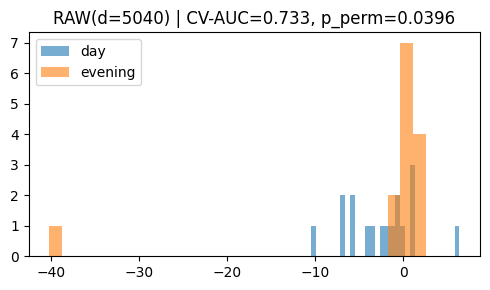

[PAIR] RAW(d=5040): недостаточно пар (n=0)


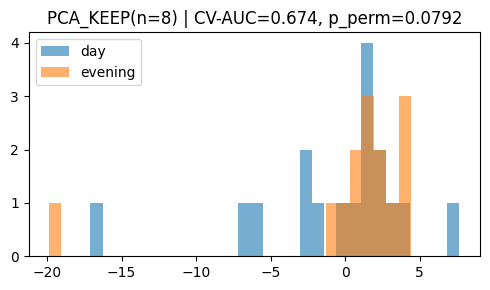

[PAIR] PCA_KEEP(n=8): недостаточно пар (n=0)


,space,CV_mean_AUC,CV_std,perm_p,n_day,n_evening,paired_p,n_pairs
0,RAW(d=5040),0.733333,0.054433,0.039604,17,14,None,0
1,PCA_KEEP(n=8),0.674444,0.174406,0.079208,17,14,None,0


In [42]:
# ==== LDA: CV-AUC (быстрый) + permutation p (быстрый), + парный Wilcoxon ====
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import wilcoxon

# ---------- QUICK SETTINGS ----------
QUICK = True                  # вкл/выкл ускорения
RANDOM_STATE = 42
N_SPLITS_MAX = 3 if QUICK else 5
N_PERM = 100 if QUICK else 500
VARIANTS = [('RAW', None), ('PCA_KEEP', 8)] if QUICK else [('RAW', None), ('PCA_KEEP', 8), ('PCA_KEEP', 12)]
LDA_SOLVER = 'svd' if QUICK else 'eigen'   # 'svd' быстрее; 'eigen' нужен для shrinkage
USE_SHRINK = False if QUICK else True
SAVE_FIGS = False
OUTDIR = './Generated/Spectral_Analysis/Diagnostics/LDA_CV_FAST'

# ---------- helpers ----------
def select_embedding(mode, keep_n=None):
    if mode == 'RAW':
        return psds_array, f'RAW(d={psds_array.shape[1]})'
    elif mode == 'PCA_KEEP':
        Z = PCA(n_components=min(keep_n, psds_array.shape[1]), random_state=RANDOM_STATE).fit_transform(psds_array)
        return Z, f'PCA_KEEP(n={Z.shape[1]})'
    else:
        return reduced_data, f'PCA_READY(n={reduced_data.shape[1]})'

def make_cv(y, n_splits_max, seed):
    # один раз считаем фолды и переиспользуем во всех перестановках
    n_pos, n_neg = int((y==1).sum()), int((y==0).sum())
    n_splits = max(2, min(n_splits_max, n_pos, n_neg))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return list(cv.split(np.zeros_like(y), y))  # индексы зависят только от y (для стратификации)

def cv_auc_given_folds(Z, y, folds, solver='svd', shrink=False):
    aucs = []
    scores = np.full(len(y), np.nan)
    for tr, te in folds:
        lda = (LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
               if (solver=='eigen' and shrink) else
               LinearDiscriminantAnalysis(solver=solver))
        lda.fit(Z[tr], y[tr])
        s = lda.decision_function(Z[te])
        scores[te] = s
        aucs.append(roc_auc_score(y[te], s))
    return float(np.mean(aucs)), np.asarray(aucs), scores

def perm_test_auc_fast(Z, y, folds, mean_auc_obs, n_perm=100, seed=0, solver='svd', shrink=False):
    rng = np.random.default_rng(seed)
    auc_perm = np.zeros(n_perm, float)
    for i in range(n_perm):
        y_perm = rng.permutation(y)
        # используем те же folds по индексам (очень ускоряет)
        auc_perm[i], _, _ = cv_auc_given_folds(Z, y_perm, folds, solver=solver, shrink=shrink)
    p_ge = (1 + (auc_perm >= mean_auc_obs).sum()) / (n_perm + 1)
    return float(p_ge), auc_perm

def plot_scores_hist(scores, y, title, save_name=None):
    s_day = scores[y==0]; s_eve = scores[y==1]
    plt.figure(figsize=(5,3))
    plt.hist(s_day, bins=30, alpha=0.6, label='day')
    plt.hist(s_eve, bins=30, alpha=0.6, label='evening')
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()
    if SAVE_FIGS:
        os.makedirs(OUTDIR, exist_ok=True)
        plt.savefig(os.path.join(OUTDIR, save_name or 'scores_hist.png'),
                    dpi=150, bbox_inches='tight')

def paired_wilcoxon(scores, subj, y):
    dfw = pd.DataFrame({'subj': subj, 'cond': np.where(y==1, 'evening', 'day'), 'score': scores})
    wide = dfw.pivot_table(index='subj', columns='cond', values='score', aggfunc='mean')
    wide = wide.dropna(subset=['day','evening'])
    if len(wide) >= 5:
        stat, p = wilcoxon(wide['day'], wide['evening'])
        return float(p), int(len(wide)), wide
    return None, int(len(wide)), wide

# ---------- данные ----------
if 'Condition' not in df.columns: raise RuntimeError("df['Condition'] не найден.")
subj_col = 'Subject_ID' if 'Subject_ID' in df.columns else ('Subject_id' if 'Subject_id' in df.columns else None)
if subj_col is None: raise RuntimeError("в df нет Subject_ID/Subject_id.")

mask = df['Condition'].isin(['day','evening']).to_numpy()
y_bin = (df.loc[mask,'Condition'] == 'evening').astype(int).to_numpy()
subj = df.loc[mask, subj_col].to_numpy()

# ---------- запуск ----------
rows = []
for mode, keep_n in VARIANTS:
    Z, tag = select_embedding(mode, keep_n)
    Z2 = Z[mask]

    folds = make_cv(y_bin, N_SPLITS_MAX, RANDOM_STATE)          # ОДИН раз
    mean_auc, aucs, scores = cv_auc_given_folds(Z2, y_bin, folds,
                                                solver=LDA_SOLVER, shrink=USE_SHRINK)
    p_perm, auc_perm = perm_test_auc_fast(Z2, y_bin, folds, mean_auc, n_perm=N_PERM,
                                          seed=RANDOM_STATE+100, solver=LDA_SOLVER, shrink=USE_SHRINK)

    plot_scores_hist(scores, y_bin, f'{tag} | CV-AUC={mean_auc:.3f}, p_perm={p_perm:.4f}',
                     save_name=f'{mode}_{keep_n}_scores.png' if keep_n else f'{mode}_scores.png')

    p_pair, n_pairs, wide = paired_wilcoxon(scores, subj, y_bin)
    if p_pair is not None:
        print(f"[PAIR] {tag}: Wilcoxon p={p_pair:.4f} (n_subjects={n_pairs})")
    else:
        print(f"[PAIR] {tag}: недостаточно пар (n={n_pairs})")

    rows.append({
        'space': tag, 'CV_mean_AUC': mean_auc, 'CV_std': float(np.std(aucs)),
        'perm_p': p_perm, 'n_day': int((y_bin==0).sum()), 'n_evening': int((y_bin==1).sum()),
        'paired_p': p_pair, 'n_pairs': n_pairs
    })

res_fast = pd.DataFrame(rows)
display(res_fast)


,space,CV_mean_AUC,CV_std,perm_p
0,RAW(d=5040),0.733333,0.054433,0.039604
1,PCA_KEEP(n=8),0.674444,0.174406,0.079208
2,PCA_KEEP(n=12),0.650556,0.101108,0.099010
3,PCA_KEEP(n=16),0.579444,0.225817,0.198020
4,PCA_KEEP(n=24),0.552778,0.108084,0.297030


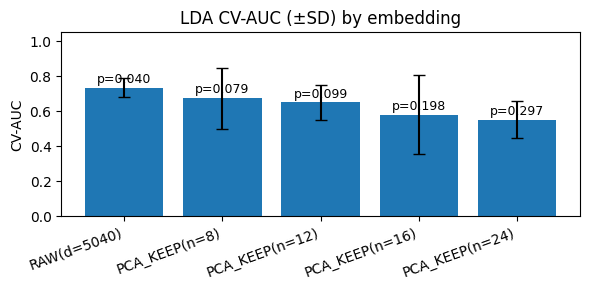

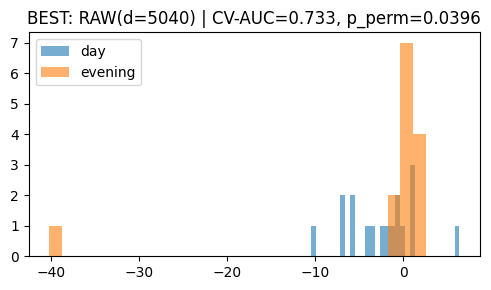

In [43]:
# ==== LDA grid: RAW vs PCA_KEEP[{8,12,16,24}] — CV-AUC + fast perm p, + гистограмма лучшего ====
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# -------- params --------
RANDOM_STATE = 42
N_SPLITS_MAX = 3          # быстро и стабильно на небольших выборках
N_PERM = 100              # быстрый perm (на итог — можно поднять до 500)
PCA_KEEP_GRID = [8, 12, 16, 24]
SAVE_FIGS = False
OUTDIR = './Generated/Spectral_Analysis/Diagnostics/LDA_GRID'

# -------- helpers --------
def select_embedding_raw_or_pca(psds_array, mode, keep_n=None):
    if mode == 'RAW':
        return psds_array, f'RAW(d={psds_array.shape[1]})'
    elif mode == 'PCA_KEEP':
        Z = PCA(n_components=min(keep_n, psds_array.shape[1]), random_state=RANDOM_STATE).fit_transform(psds_array)
        return Z, f'PCA_KEEP(n={Z.shape[1]})'
    else:
        raise ValueError("mode must be 'RAW' or 'PCA_KEEP'")

def make_cv_folds(y, n_splits_max, seed):
    n_pos, n_neg = int((y==1).sum()), int((y==0).sum())
    n_splits = max(2, min(n_splits_max, n_pos, n_neg))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return list(cv.split(np.zeros_like(y), y))

def cv_auc_given_folds(Z, y, folds):
    aucs, scores = [], np.full(len(y), np.nan)
    for tr, te in folds:
        lda = LinearDiscriminantAnalysis(solver='svd')  # быстро и стабильно
        lda.fit(Z[tr], y[tr])
        s = lda.decision_function(Z[te])
        scores[te] = s
        aucs.append(roc_auc_score(y[te], s))
    return float(np.mean(aucs)), float(np.std(aucs)), scores

def perm_test_auc_fast(Z, y, folds, mean_auc_obs, n_perm=100, seed=0):
    rng = np.random.default_rng(seed)
    auc_perm = np.zeros(n_perm, float)
    for i in range(n_perm):
        y_perm = rng.permutation(y)
        auc_perm[i], _, _ = cv_auc_given_folds(Z, y_perm, folds)
    p_ge = (1 + (auc_perm >= mean_auc_obs).sum()) / (n_perm + 1)
    return float(p_ge), auc_perm

def maybe_save_current(name):
    if SAVE_FIGS:
        os.makedirs(OUTDIR, exist_ok=True)
        plt.savefig(os.path.join(OUTDIR, name), dpi=150, bbox_inches='tight')

# -------- data subset --------
if 'Condition' not in df.columns:
    raise RuntimeError("df['Condition'] не найден — сначала сформируй Time/Condition.")
mask_de = df['Condition'].isin(['day','evening']).to_numpy()
y_bin = (df.loc[mask_de, 'Condition'] == 'evening').astype(int).to_numpy()

# -------- run grid --------
variants = [('RAW', None)] + [('PCA_KEEP', n) for n in PCA_KEEP_GRID]
rows = []
best = None

for mode, keep_n in variants:
    Z, tag = select_embedding_raw_or_pca(psds_array, mode, keep_n)
    Z2 = Z[mask_de]

    folds = make_cv_folds(y_bin, N_SPLITS_MAX, RANDOM_STATE)
    mean_auc, std_auc, scores = cv_auc_given_folds(Z2, y_bin, folds)
    p_perm, auc_perm = perm_test_auc_fast(Z2, y_bin, folds, mean_auc, n_perm=N_PERM, seed=RANDOM_STATE+100)

    rows.append({'space': tag, 'CV_mean_AUC': mean_auc, 'CV_std': std_auc, 'perm_p': p_perm})
    if (best is None) or (mean_auc > best['CV_mean_AUC']):
        best = {'space': tag, 'scores': scores, 'y': y_bin, 'CV_mean_AUC': mean_auc, 'perm_p': p_perm}

# -------- summary table --------
res = pd.DataFrame(rows).sort_values('CV_mean_AUC', ascending=False).reset_index(drop=True)
display(res)

# -------- bar chart --------
plt.figure(figsize=(6,3))
x = np.arange(len(res))
plt.bar(x, res['CV_mean_AUC'], yerr=res['CV_std'], capsize=4)
plt.xticks(x, res['space'], rotation=20, ha='right')
plt.ylabel('CV-AUC')
plt.title('LDA CV-AUC (±SD) by embedding')
for i, (auc, p) in enumerate(zip(res['CV_mean_AUC'], res['perm_p'])):
    plt.text(i, auc+0.01, f"p={p:.3f}", ha='center', va='bottom', fontsize=9)
plt.ylim(0, 1.05)
plt.tight_layout(); maybe_save_current('lda_grid_bar.png'); plt.show()

# -------- histogram for BEST variant --------
s_day = best['scores'][best['y']==0]; s_eve = best['scores'][best['y']==1]
plt.figure(figsize=(5,3))
plt.hist(s_day, bins=30, alpha=0.6, label='day')
plt.hist(s_eve, bins=30, alpha=0.6, label='evening')
plt.title(f"BEST: {best['space']} | CV-AUC={best['CV_mean_AUC']:.3f}, p_perm={best['perm_p']:.4f}")
plt.legend(); plt.tight_layout(); maybe_save_current('lda_grid_best_hist.png'); plt.show()
